# Does the gradient target survive a sampler?

A go/no-go diagnostic for the TV posterior-mean example (`work2.tex` Instantiation B). It trains nothing
and recovers no prior. It answers one question, before we build anything on top of the answer.

## The question

`posterior_mean_l1.ipynb` recovers a prior from denoiser evaluations alone, using the exact target

$$\nabla f_{reg}(\mathbf{y}_k) = \mathbf{x}_k - \mathbf{y}_k, \qquad \mathbf{y}_k = u_{PM}(\mathbf{x}_k).$$

There, $u_{PM}$ is a closed form and $\mathbf{y}_k$ is exact. For a TV prior there is no closed form:
$\mathbf{y}_k$ comes from an MCMC posterior-mean sampler, so we get $\hat{\mathbf{y}}_k = \mathbf{y}_k +
\boldsymbol{\delta}$. **Both the target and the point it is attached to are then wrong at $O(\delta)$** ---
no cancellation, because the target *is* a difference of the two.

That matters because of what we gave up. The *value* target $f_{reg}(\mathbf{y}_k) = \langle\mathbf{x}_k,
\mathbf{y}_k\rangle - \psi(\mathbf{x}_k) - \tfrac12\|\mathbf{y}_k\|^2$ is $O(\delta^2)$-robust: Fenchel--Young
says it is a *minorant* whose gap vanishes to first order at $\hat{\mathbf{y}}_k = \nabla\psi(\mathbf{x}_k)$.
But it needs $S_\varepsilon$, a log-partition function, which is exactly what the sampler cannot cheaply give.
So the channel we can afford is the fragile one, and the signal is small: $\|\mathbf{x}-\mathbf{y}\|$ is the
denoising increment, order $\sigma$.

**The measurement.** Run several independent chains per $\mathbf{x}_k$. Their spread estimates $\delta$ for
one chain. Compare it to $\|\mathbf{x}_k - \mathbf{y}_k\|$. Report the relative error on the gradient target,
how it decays with sweeps, and what each level costs at the $N$ a real run needs.

In [1]:
import os
import sys
import time

import numpy as np

HERE = os.path.abspath(".")
sys.path.insert(0, HERE)
from tvpm.sampler import load_image_file as load_image, params, sample_pm

%matplotlib inline
import matplotlib.pyplot as plt

SCALE = 256
SIGMA, LAM = 10 / SCALE, 32 / SCALE     # the MATLAB's tabulated pair (factor=10)
EPS, T = params(SIGMA, LAM)
N_X, N_CHAINS = 16, 8                   # 16 distinct x_k, 8 chains each
BARBARA = os.path.join(HERE, "..", "..", "ideas", "old_files", "barbara_512x512.png")

print(f"sigma={SIGMA:.4f}  lam={LAM:.4f}  eps={EPS:.5f}  t={T:.4f}  "
      f"(t=lam/2, sqrt(t*eps)=sigma)")


sigma=0.0391  lam=0.1250  eps=0.02441  t=0.0625  (t=lam/2, sqrt(t*eps)=sigma)


## The data

$\mathbf{x}_k$ = a clean Barbara patch + Gaussian noise, which is what the regime actually presents. Two
sizes, to see how $\delta$ scales with $n$: $8\times8$ ($n=64$) and $16\times16$ ($n=256$).

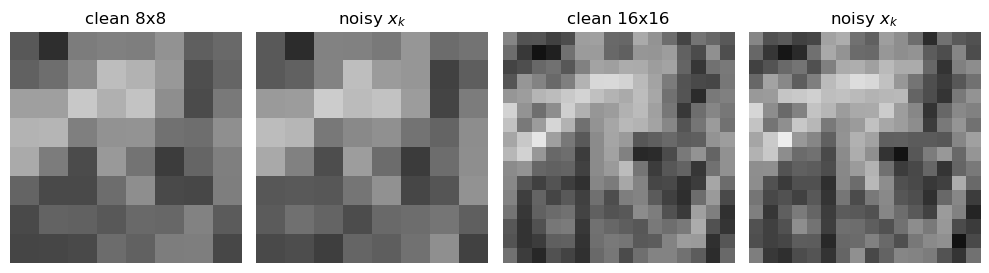

In [2]:
def make_x(size, n_x, seed=0):
    clean = load_image(BARBARA, size)
    rng = np.random.default_rng(seed)
    return clean, (clean[None] + rng.normal(0, SIGMA, (n_x, size, size))).clip(0, 1)

fig, ax = plt.subplots(1, 4, figsize=(10, 2.7))
for j, size in enumerate((8, 16)):
    clean, x = make_x(size, N_X)
    ax[2*j].imshow(clean, cmap="gray", vmin=0, vmax=1); ax[2*j].set_title(f"clean {size}x{size}")
    ax[2*j+1].imshow(x[0], cmap="gray", vmin=0, vmax=1); ax[2*j+1].set_title("noisy $x_k$")
for a in ax: a.axis("off")
fig.tight_layout(); plt.show()

## The measurement

For each $\mathbf{x}_k$ we run `N_CHAINS` independent chains. The standard deviation across chains is an
unbiased estimate of $\delta$, the error of *one* chain's $u_{PM}$ --- which is what a real run would use,
since it can afford one chain per $\mathbf{x}_k$ and no more.

Errors are reported in the norm the target actually lives in: $\|\boldsymbol{\delta}\|_2 = (\sum_i
\mathrm{Var}(\hat y_i))^{1/2}$ against $\|\mathbf{x}_k - \bar{\mathbf{y}}_k\|_2$.

In [3]:
def measure(size, sweeps_grid):
    clean, x = make_x(size, N_X)
    xb = np.repeat(x, N_CHAINS, axis=0)                 # (N_X*N_CHAINS, size, size)
    rows = []
    for sw in sweeps_grid:
        t0 = time.time()
        out = sample_pm(xb, SIGMA, LAM, sweeps=sw, seed=11)
        secs = time.time() - t0
        y = out["u_pm"].reshape(N_X, N_CHAINS, size, size)

        delta = y.std(axis=1, ddof=1)                   # per-pixel error of ONE chain
        ybar = y.mean(axis=1)                           # best estimate of u_PM
        noise = np.sqrt((delta ** 2).sum(axis=(1, 2)))  # ||delta||_2 per x_k
        signal = np.linalg.norm((x - ybar).reshape(N_X, -1), axis=1)
        rows.append({"n": size * size, "sweeps": sw,
                     "signal": float(np.mean(signal)), "noise": float(np.mean(noise)),
                     "rel %": float(100 * np.mean(noise / signal)),
                     "accept": out["accept"],
                     "sec/chain": secs / xb.shape[0]})
        print(f"  n={size*size:4d}  sweeps={sw:6d}  ||x-y||={rows[-1]['signal']:.4f}  "
              f"||delta||={rows[-1]['noise']:.4f}  ->  {rows[-1]['rel %']:6.2f}% "
              f"  ({secs:.0f}s, accept {out['accept']:.2f})")
    return rows

SWEEPS = (500, 2000, 8000, 32000)
print("relative error on the gradient target x_k - y_k:")
res = measure(8, SWEEPS) + measure(16, SWEEPS)

relative error on the gradient target x_k - y_k:


  n=  64  sweeps=   500  ||x-y||=0.6125  ||delta||=0.0291  ->    4.75%   (0s, accept 0.40)


  n=  64  sweeps=  2000  ||x-y||=0.6115  ||delta||=0.0145  ->    2.37%   (1s, accept 0.40)


  n=  64  sweeps=  8000  ||x-y||=0.6118  ||delta||=0.0073  ->    1.20%   (4s, accept 0.40)


  n=  64  sweeps= 32000  ||x-y||=0.6117  ||delta||=0.0036  ->    0.59%   (17s, accept 0.40)


  n= 256  sweeps=   500  ||x-y||=1.3064  ||delta||=0.0564  ->    4.32%   (1s, accept 0.40)


  n= 256  sweeps=  2000  ||x-y||=1.3058  ||delta||=0.0282  ->    2.16%   (3s, accept 0.39)


  n= 256  sweeps=  8000  ||x-y||=1.3060  ||delta||=0.0141  ->    1.08%   (13s, accept 0.39)


  n= 256  sweeps= 32000  ||x-y||=1.3059  ||delta||=0.0071  ->    0.54%   (50s, accept 0.39)


In [4]:
import pandas as pd
pd.options.display.float_format = lambda v: f"{v:.4g}"
tab = pd.DataFrame(res).set_index(["n", "sweeps"])
tab

signal    noise  rel %  accept  sec/chain
n   sweeps                                           
64  500     0.6125  0.02911   4.75  0.3987   0.002058
    2000    0.6115  0.01449  2.369  0.3972   0.008442
    8000    0.6118 0.007329  1.198  0.3969    0.03297
    32000   0.6117 0.003619  0.592  0.3968     0.1292
256 500      1.306  0.05643  4.319  0.3964   0.006149
    2000     1.306   0.0282   2.16  0.3948    0.02453
    8000     1.306  0.01411  1.081  0.3942    0.09834
    32000    1.306 0.007111 0.5446  0.3941     0.3923

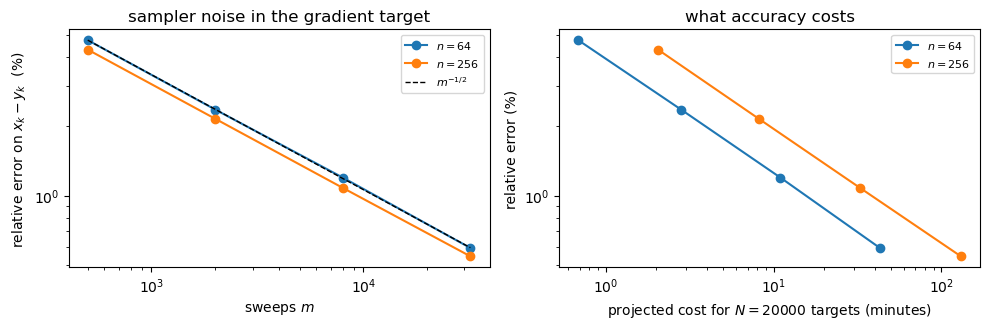

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
for n in (64, 256):
    r = [d for d in res if d["n"] == n]
    sw = [d["sweeps"] for d in r]
    ax[0].loglog(sw, [d["rel %"] for d in r], "o-", label=f"$n={n}$")
    ax[1].loglog([d["sec/chain"] * 20000 / 60 for d in r], [d["rel %"] for d in r],
                 "o-", label=f"$n={n}$")
ref = np.array(SWEEPS, dtype=float)
r0 = [d for d in res if d["n"] == 64][0]
ax[0].loglog(ref, r0["rel %"] * np.sqrt(ref[0] / ref), "k--", lw=1, label=r"$m^{-1/2}$")
ax[0].set_xlabel("sweeps $m$"); ax[0].set_ylabel("relative error on $x_k-y_k$  (%)")
ax[0].set_title("sampler noise in the gradient target"); ax[0].legend(fontsize=8)
ax[1].set_xlabel("projected cost for $N=20000$ targets (minutes)")
ax[1].set_ylabel("relative error (%)"); ax[1].set_title("what accuracy costs")
ax[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

## Reading

The number to weigh is the relative error on $\mathbf{x}_k - \mathbf{y}_k$, against the $0.0076\%$ that the
$\ell^1$ example reached with an exact target. Two things soften it, and one sharpens it.

**Softening.** The network *regresses* through the noise: with $N$ samples and an $O(\delta)$ i.i.d. error
per target, the fitted $\nabla J_\theta$ averages, so the recovered prior should be better than any single
target. And the certificate does not care about the constant, so it stays usable.

**Sharpening.** $\boldsymbol\delta$ moves the *location* $\hat{\mathbf{y}}_k$ too, which is errors-in-variables,
not additive output noise --- that biases a fit rather than averaging out of it. Whether the bias matters
depends on $\delta$ against the curvature scale of $f_{reg}$, which we cannot measure without a ground
truth we do not have.

The cost panel is the decision: it says what $N=20000$ targets cost at each accuracy, on one CPU.